# 2D Phase Diagram Analysis

This notebook reproduces the characterization done in `run_experiments_2d_phase_diagram.py`, but in notebook form so you can edit plotting choices interactively.

It loads the per-run CSV for the full sweep and optionally reads `runs/*.json` from the same cache directory to recover training dynamics.

## What Are The Black Lines In The Heatmaps?

They are contour lines overlaid on the heatmap. In the script, the contour is drawn at accuracy `0.15`, slightly above chance (`0.10` for 10 classes), to trace an approximate phase boundary.

In the script this comes from `ax.contour(... levels=[contour_threshold], ...)` with `contour_threshold = 0.15`.

In [32]:
from pathlib import Path
import importlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

CWD = Path.cwd().resolve()
search_roots = [CWD, *CWD.parents]
csv_candidates = []
for root in search_roots:
    csv_candidates.extend(root.glob('phase2d_*/data/results_per_run_phase2d_*.csv'))
    csv_candidates.extend(root.glob('noisy_mnist/phase_diagram_2d/phase2d_*/data/results_per_run_phase2d_*.csv'))
csv_candidates = sorted({p.resolve() for p in csv_candidates}, key=lambda p: p.stat().st_mtime)
if not csv_candidates:
    raise FileNotFoundError('No matching per-run CSV found from the current working directory or its parents.')

# Pick the newest matching cache by default. Override this manually if you want a different run.
CSV_PATH = csv_candidates[-1]

CACHE_DIR = CSV_PATH.parents[1]
RUNS_DIR = CACHE_DIR / 'runs'
FIGURES_DIR = CACHE_DIR / 'figures_notebook'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PHASE_THRESHOLDS = (0.15, 0.20)
CHANCE_ACCURACY = 0.10
SCALING_BATCHES = [64, 256, 1024]


def save_figure(fig, stem: str):
    fig.savefig(FIGURES_DIR / f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'{stem}.png', bbox_inches='tight', dpi=200)

CSV_PATH, CACHE_DIR, RUNS_DIR, FIGURES_DIR

(PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500/data/results_per_run_phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500.csv'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500/runs'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500/figures_notebook'))

In [33]:
df = pd.read_csv(CSV_PATH)
df = df.sort_values(['N', 'batch_size', 'p', 'seed']).reset_index(drop=True)
df.head()

,p,batch_size,effective_batch_size,N,seed,width,total_samples_seen,num_steps,final_test_accuracy,final_test_loss
0,0.9,16,16,5000,0,512,250000,15625,0.7516,0.728471
1,0.9,16,16,5000,1,512,250000,15625,0.7456,0.753436
2,0.9,16,16,5000,2,512,250000,15625,0.7464,0.743198
3,0.9,16,16,5000,3,512,250000,15625,0.7432,0.754311
4,0.9,16,16,5000,4,512,250000,15625,0.7525,0.747386


In [34]:
def aggregate_by_mean(frame: pd.DataFrame) -> pd.DataFrame:
    agg_kwargs = {
        'mean_accuracy': ('final_test_accuracy', 'mean'),
        'std_accuracy': ('final_test_accuracy', 'std'),
        'count': ('final_test_accuracy', 'count'),
    }
    if 'final_test_loss' in frame.columns:
        agg_kwargs['mean_loss'] = ('final_test_loss', 'mean')
    grouped = frame.groupby(['N', 'batch_size', 'p'], as_index=False).agg(**agg_kwargs)
    if 'mean_loss' not in grouped.columns:
        grouped['mean_loss'] = np.nan
    grouped['std_accuracy'] = grouped['std_accuracy'].fillna(0.0)
    grouped['stderr_accuracy'] = grouped['std_accuracy'] / np.sqrt(grouped['count'].clip(lower=1))
    return grouped


def aggregate_accuracy_only(frame: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        frame.groupby(['N', 'batch_size', 'p'], as_index=False)
        .agg(
            mean_accuracy=('final_test_accuracy', 'mean'),
            std_accuracy=('final_test_accuracy', 'std'),
            count=('final_test_accuracy', 'count'),
        )
    )
    grouped['std_accuracy'] = grouped['std_accuracy'].fillna(0.0)
    grouped['stderr_accuracy'] = grouped['std_accuracy'] / np.sqrt(grouped['count'].clip(lower=1))
    return grouped


def enforce_nonincreasing(values):
    values = list(map(float, values))
    if not values:
        return []
    out = [values[0]]
    for value in values[1:]:
        out.append(min(out[-1], value))
    return out


def estimate_crossing(ps, accs, threshold):
    ps = list(map(float, ps))
    accs = enforce_nonincreasing(accs)
    if len(ps) < 2:
        return None
    for i in range(1, len(ps)):
        prev_acc = accs[i - 1]
        curr_acc = accs[i]
        if prev_acc >= threshold >= curr_acc:
            p0 = ps[i - 1]
            p1 = ps[i]
            if abs(curr_acc - prev_acc) < 1e-12:
                return p1
            frac = (threshold - prev_acc) / (curr_acc - prev_acc)
            return p0 + frac * (p1 - p0)
    return None


def fit_phase_boundary(batch_sizes, p_critical):
    valid = [
        (float(batch_size), float(pc))
        for batch_size, pc in zip(batch_sizes, p_critical)
        if np.isfinite(pc) and 0.0 < 1.0 - pc < 1.0
    ]
    if len(valid) < 2:
        return None
    x = np.log([batch_size for batch_size, _ in valid])
    y = np.log([1.0 - pc for _, pc in valid])
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = intercept + slope * x
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return {
        'a': float(np.exp(intercept)),
        'beta': float(-slope),
        'r2': float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }


def linear_edges(values):
    vals = np.asarray(sorted(values), dtype=float)
    if vals.size == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5], dtype=float)
    mids = 0.5 * (vals[:-1] + vals[1:])
    edges = np.empty(vals.size + 1, dtype=float)
    edges[1:-1] = mids
    edges[0] = vals[0] - (mids[0] - vals[0])
    edges[-1] = vals[-1] + (vals[-1] - mids[-1])
    return edges


def log_edges(values):
    vals = np.asarray(sorted(values), dtype=float)
    if vals.size == 1:
        return np.array([vals[0] / 2.0, vals[0] * 2.0], dtype=float)
    mids = np.sqrt(vals[:-1] * vals[1:])
    edges = np.empty(vals.size + 1, dtype=float)
    edges[1:-1] = mids
    edges[0] = vals[0] ** 2 / mids[0]
    edges[-1] = vals[-1] ** 2 / mids[-1]
    return edges


def build_heatmap_grid(agg, n_value, batch_sizes, p_values):
    pivot = (
        agg[agg['N'] == n_value]
        .pivot(index='batch_size', columns='p', values='mean_accuracy')
        .reindex(index=batch_sizes, columns=p_values)
    )
    return pivot.to_numpy(dtype=float)


def add_heatmap(ax, batch_sizes, p_values, grid, title, contour_threshold=0.15, cmap='coolwarm'):
    norm = TwoSlopeNorm(vmin=0.0, vcenter=CHANCE_ACCURACY, vmax=1.0)
    mesh = ax.pcolormesh(
        linear_edges(p_values),
        log_edges(batch_sizes),
        grid,
        shading='auto',
        cmap=cmap,
        norm=norm,
    )
    if np.isfinite(grid).sum() >= 4:
        p_mesh, b_mesh = np.meshgrid(p_values, batch_sizes)
        try:
            ax.contour(
                p_mesh,
                b_mesh,
                grid,
                levels=[contour_threshold],
                colors='black',
                linewidths=1.1,
            )
        except ValueError:
            pass
    ax.set_title(title)
    ax.set_xlabel('corruption probability p')
    ax.set_ylabel('batch size')
    ax.set_yscale('log')
    ax.set_yticks(batch_sizes)
    ax.set_yticklabels([str(v) for v in batch_sizes])
    return mesh


def scaling_collapse_score(scaled_x, y, bins=30):
    scaled_x = np.asarray(scaled_x, dtype=float)
    y = np.asarray(y, dtype=float)
    if scaled_x.size < 6:
        return np.inf
    grid = np.linspace(float(scaled_x.min()), float(scaled_x.max()), bins + 1)
    score = 0.0
    used = 0
    for idx in range(bins):
        left = grid[idx]
        right = grid[idx + 1]
        if idx == bins - 1:
            mask = (scaled_x >= left) & (scaled_x <= right)
        else:
            mask = (scaled_x >= left) & (scaled_x < right)
        if mask.sum() < 2:
            continue
        score += float(np.var(y[mask]))
        used += 1
    return np.inf if used == 0 else score / used


def find_best_nu(ps, ns, accs, p_critical):
    best_nu = 1.0
    best_score = np.inf
    for nu in np.linspace(0.2, 5.0, 97):
        scaled_x = (ps - p_critical) * np.power(ns, 1.0 / nu)
        score = scaling_collapse_score(scaled_x, accs)
        if score < best_score:
            best_score = score
            best_nu = float(nu)
    return best_nu


def find_best_pc_nu(frame: pd.DataFrame, acc_window=(0.12, 0.78), p_grid_size=121, nu_grid_size=97):
    work = frame.copy().sort_values(['N', 'p'])
    if len(work['N'].unique()) < 2 or len(work['p'].unique()) < 4:
        return None

    lo, hi = acc_window
    windowed = work[(work['mean_accuracy'] >= lo) & (work['mean_accuracy'] <= hi)].copy()
    if len(windowed) >= 8:
        work = windowed

    ps = work['p'].to_numpy(dtype=float)
    ns = work['N'].to_numpy(dtype=float)
    accs = work['mean_accuracy'].to_numpy(dtype=float)

    p_min = float(np.min(ps)) + 1e-4
    p_max = float(np.max(ps)) - 1e-4
    if not p_max > p_min:
        return None

    p_candidates = np.linspace(p_min, p_max, p_grid_size)
    nu_candidates = np.linspace(0.2, 5.0, nu_grid_size)
    best = None
    best_score = np.inf

    for p_c in p_candidates:
        for nu in nu_candidates:
            scaled_x = (ps - p_c) * np.power(ns, 1.0 / nu)
            score = scaling_collapse_score(scaled_x, accs)
            if score < best_score:
                best_score = score
                best = {
                    'p_c': float(p_c),
                    'nu': float(nu),
                    'score': float(score),
                    'n_points': int(len(work)),
                }
    return best


def interpolate_accuracy_at_pc(frame: pd.DataFrame, p_c: float):
    values = []
    for n_value in sorted(frame['N'].unique()):
        sub = frame[frame['N'] == n_value].sort_values('p')
        ps = sub['p'].to_numpy(dtype=float)
        accs = sub['mean_accuracy'].to_numpy(dtype=float)
        if len(ps) < 2 or p_c < ps.min() or p_c > ps.max():
            continue
        values.append(float(np.interp(p_c, ps, accs)))
    if not values:
        return np.nan
    return float(np.mean(values))


def find_best_full_collapse(frame: pd.DataFrame, acc_window=(0.12, 0.78), p_grid_size=41, nu_grid_size=49, kappa_grid_size=81):
    base = find_best_pc_nu(frame, acc_window=acc_window, p_grid_size=max(31, p_grid_size), nu_grid_size=max(31, nu_grid_size))
    if base is None:
        return None

    work = frame.copy().sort_values(['N', 'p'])
    lo, hi = acc_window
    windowed = work[(work['mean_accuracy'] >= lo) & (work['mean_accuracy'] <= hi)].copy()
    if len(windowed) >= 8:
        work = windowed

    ps = work['p'].to_numpy(dtype=float)
    ns = work['N'].to_numpy(dtype=float)
    accs = work['mean_accuracy'].to_numpy(dtype=float)

    p_min_data = float(np.min(ps)) + 1e-4
    p_max_data = float(np.max(ps)) - 1e-4
    p_half_width = min(0.02, 0.5 * max(1e-4, p_max_data - p_min_data))
    p_min = max(p_min_data, float(base['p_c']) - p_half_width)
    p_max = min(p_max_data, float(base['p_c']) + p_half_width)
    if not p_max > p_min:
        p_min, p_max = p_min_data, p_max_data

    nu_min = max(0.2, 0.5 * float(base['nu']))
    nu_max = min(8.0, 2.0 * float(base['nu']))
    if not nu_max > nu_min:
        nu_min, nu_max = 0.2, 5.0

    p_candidates = np.linspace(p_min, p_max, p_grid_size)
    nu_candidates = np.linspace(nu_min, nu_max, nu_grid_size)
    kappa_candidates = np.linspace(-2.0, 2.0, kappa_grid_size)

    best = None
    best_score = np.inf
    for p_c in p_candidates:
        a_c = interpolate_accuracy_at_pc(work, float(p_c))
        if not np.isfinite(a_c):
            continue
        for nu in nu_candidates:
            scaled_x = (ps - p_c) * np.power(ns, 1.0 / nu)
            for kappa in kappa_candidates:
                scaled_y = (accs - a_c) * np.power(ns, kappa)
                score = scaling_collapse_score(scaled_x, scaled_y)
                if score < best_score:
                    best_score = score
                    best = {
                        'p_c': float(p_c),
                        'nu': float(nu),
                        'A_c': float(a_c),
                        'kappa': float(kappa),
                        'score': float(score),
                        'n_points': int(len(work)),
                    }
    return best


def import_fssa_with_compat():
    if not hasattr(np, 'int'):
        np.int = int
    try:
        import scipy.optimize.optimize as _opt_mod
        _opt_mod = importlib.reload(_opt_mod)
        from scipy.optimize import _optimize as _opt
        for name in ('OptimizeResult', '_status_message', 'wrap_function'):
            if not hasattr(_opt_mod, name) and hasattr(_opt, name):
                setattr(_opt_mod, name, getattr(_opt, name))
        if not hasattr(_opt_mod, 'wrap_function'):
            def _wrap_function(function, args):
                ncalls = [0]
                def function_wrapper(x):
                    ncalls[0] += 1
                    return function(x, *args)
                return ncalls, function_wrapper
            _opt_mod.wrap_function = _wrap_function
    except Exception:
        pass
    import fssa
    return fssa


def find_pyfssa_collapse_zeta0_batch(frame: pd.DataFrame, rho_grid_size=40, nu_grid_size=60):
    sub = frame.copy().sort_values(['N', 'p'])
    n_sizes = sorted(sub['N'].unique().tolist())
    if len(n_sizes) < 2:
        return {'error': f'need >=2 N values, found {n_sizes}'}, None

    common_p = None
    for n_value in n_sizes:
        pset = set(sub.loc[sub['N'] == n_value, 'p'].astype(float).tolist())
        common_p = pset if common_p is None else (common_p & pset)
    p_values = sorted(common_p) if common_p else []
    if len(p_values) < 2:
        return {'error': 'need >=2 common p values across N'}, None

    p_set = set(p_values)
    sub = sub[sub['p'].isin(p_set)].copy()
    L = np.array(n_sizes, dtype=float)
    rho = np.array(p_values, dtype=float)
    a = np.zeros((len(L), len(rho)))
    da = np.zeros_like(a)
    for i, n_value in enumerate(n_sizes):
        d = sub[sub['N'] == n_value].set_index('p')
        for j, p in enumerate(p_values):
            row = d.loc[p]
            a[i, j] = float(row['mean_accuracy'])
            da[i, j] = float(row.get('stderr_accuracy', 0.0))
    min_nonzero = da[da > 0].min() if np.any(da > 0) else 1e-6
    da = np.where(np.isfinite(da), da, min_nonzero)
    da = np.clip(da, 1e-6, None)

    try:
        fssa = import_fssa_with_compat()
    except Exception as exc:
        return {'error': f'fssa import failed: {exc}'}, None

    zeta_fixed = 0.0
    rho_grid = np.linspace(float(rho.min()) + 1e-3, float(rho.max()) - 1e-3, rho_grid_size)
    nu_grid = np.linspace(0.2, 10.0, nu_grid_size)
    best = (float('inf'), np.nan, np.nan)
    for rho_c in rho_grid:
        for nu in nu_grid:
            scaled = fssa.scaledata(L, rho, a, da, rho_c, nu, zeta_fixed)
            s_val = fssa.quality(scaled.x, scaled.y, scaled.dy)
            if s_val < best[0]:
                best = (float(s_val), float(rho_c), float(nu))
    s_star, rho_c_star, nu_star = best
    if not np.isfinite(s_star):
        return {'error': 'failed to find finite pyfssa quality'}, None

    scaled = fssa.scaledata(L, rho, a, da, rho_c_star, nu_star, zeta_fixed)
    result = {
        'rho_c': rho_c_star,
        'nu': nu_star,
        'zeta': zeta_fixed,
        'S': s_star,
        'n_values': [int(v) for v in n_sizes],
    }
    return result, scaled


agg = aggregate_by_mean(df)
batch_sizes = sorted(df['batch_size'].unique().tolist())
p_values = sorted(df['p'].unique().tolist())
n_values = sorted(df['N'].unique().tolist())

agg.head()

,N,batch_size,p,mean_accuracy,std_accuracy,count,mean_loss,stderr_accuracy
0,5000,16,0.900000,0.74786,0.004015,5,0.745360,0.001795
1,5000,16,0.903276,0.74716,0.004004,5,0.746566,0.001791
2,5000,16,0.906552,0.74598,0.003517,5,0.750014,0.001573
3,5000,16,0.909828,0.74482,0.003530,5,0.753981,0.001579
4,5000,16,0.913103,0.74408,0.004055,5,0.761430,0.001813


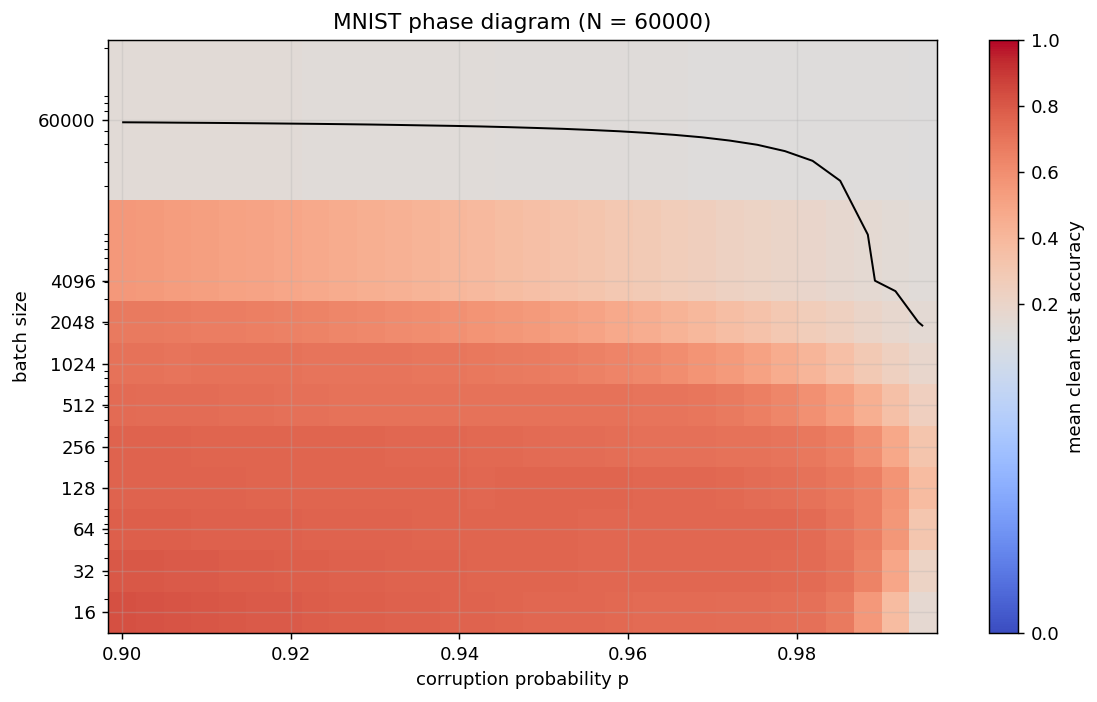

In [35]:
fig, ax = plt.subplots(figsize=(9, 5.5))
grid = build_heatmap_grid(agg, 60000, batch_sizes, p_values)
mesh = add_heatmap(
    ax,
    batch_sizes=batch_sizes,
    p_values=p_values,
    grid=grid,
    title='MNIST phase diagram (N = 60000)',
    contour_threshold=0.15,
)
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('mean clean test accuracy')
fig.tight_layout()
save_figure(fig, 'heatmap_N60000_notebook')
plt.show()
plt.close(fig)

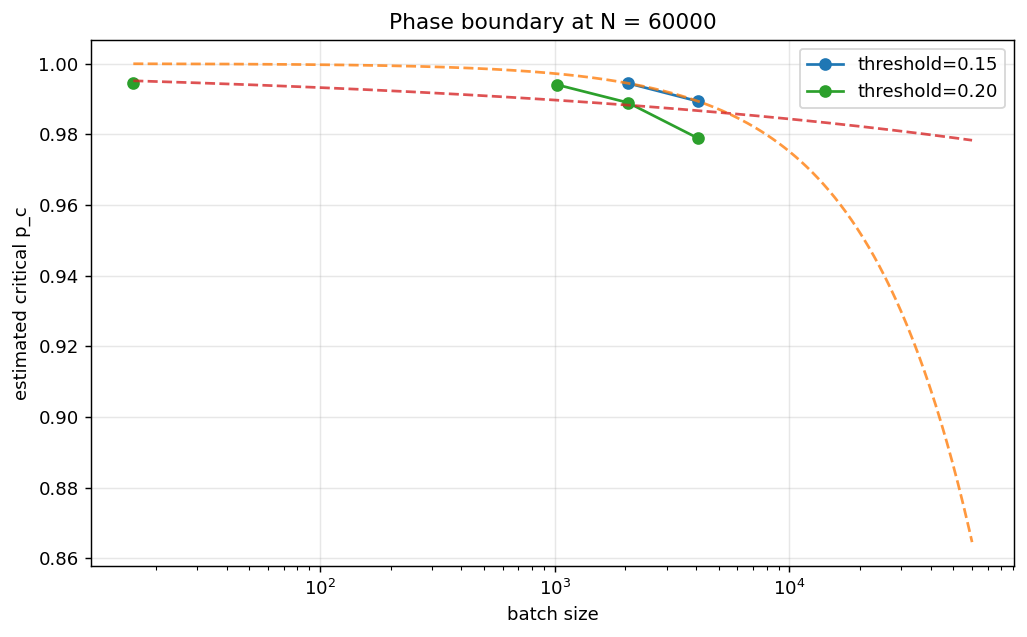

,threshold,a,beta,r2
0,0.15,0.000004,-0.945138,1.000000
1,0.20,0.002946,-0.181480,0.532625


In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
fit_table = []

for threshold in PHASE_THRESHOLDS:
    pcs = []
    for batch_size in batch_sizes:
        sub = agg[(agg['N'] == 60000) & (agg['batch_size'] == batch_size)].sort_values('p')
        pc = estimate_crossing(sub['p'], sub['mean_accuracy'], threshold)
        pcs.append(np.nan if pc is None else pc)
    ax.plot(batch_sizes, pcs, marker='o', label=f'threshold={threshold:.2f}')
    fit = fit_phase_boundary(batch_sizes, pcs)
    if fit is not None:
        batch_grid = np.geomspace(min(batch_sizes), max(batch_sizes), 300)
        ax.plot(batch_grid, 1.0 - fit['a'] * np.power(batch_grid, -fit['beta']), linestyle='--', alpha=0.8)
        fit_table.append({'threshold': threshold, **fit})

ax.set_xscale('log')
ax.set_xlabel('batch size')
ax.set_ylabel('estimated critical p_c')
ax.set_title('Phase boundary at N = 60000')
ax.legend()
fig.tight_layout()
save_figure(fig, 'phase_boundary_notebook')
plt.show()
plt.close(fig)

pd.DataFrame(fit_table)

/tmp/ipykernel_829870/2643454361.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 1])


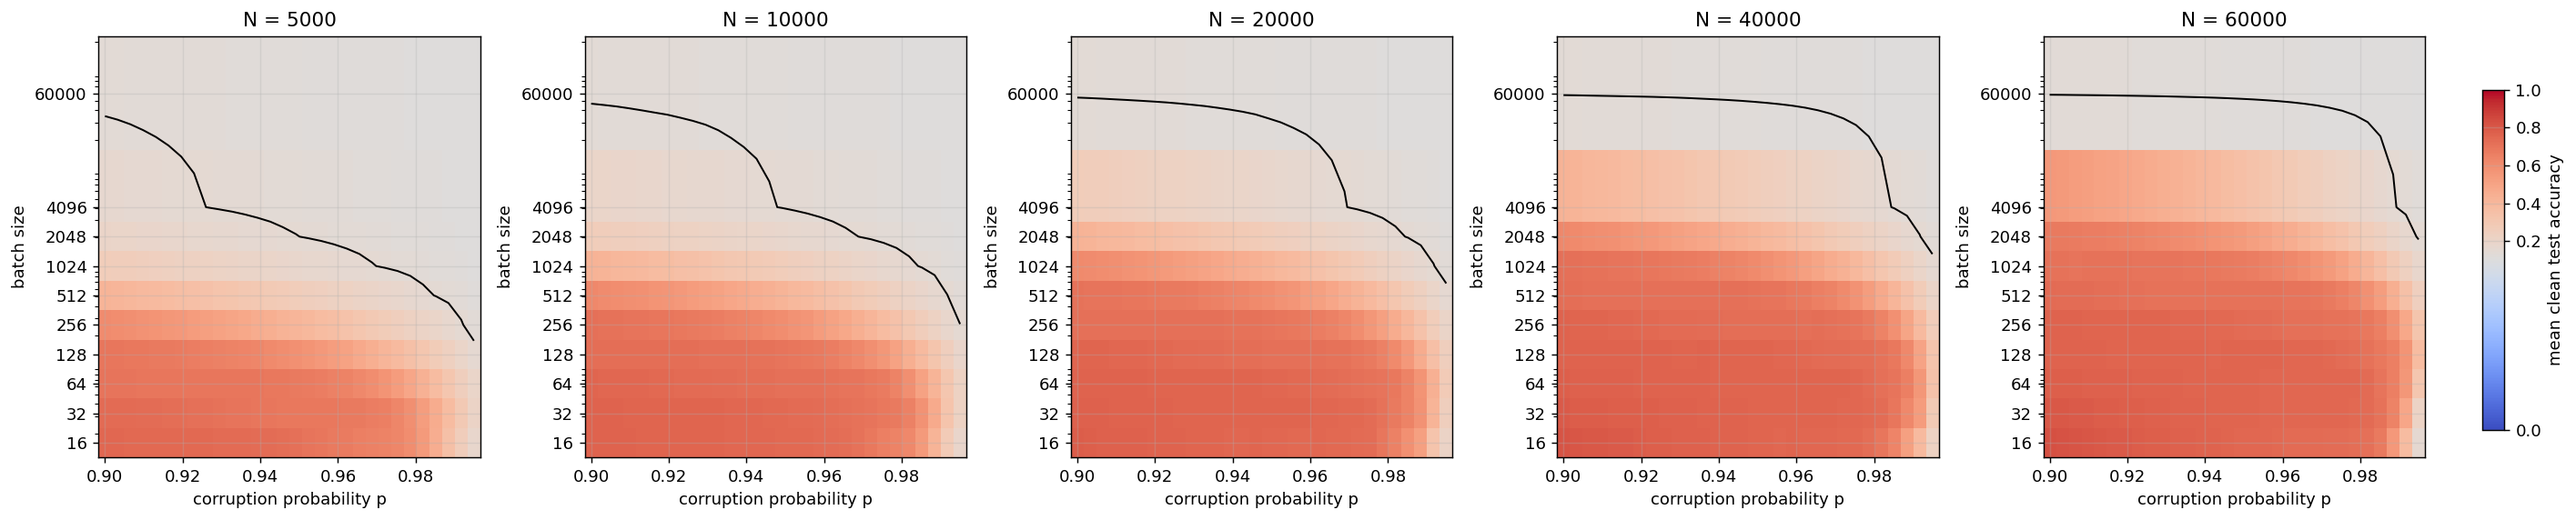

In [37]:
fig, axes = plt.subplots(1, len(n_values), figsize=(4.5 * len(n_values), 4.5), squeeze=False)
fig.subplots_adjust(right=0.92)
mesh = None
for idx, n_value in enumerate(n_values):
    ax = axes[0, idx]
    grid = build_heatmap_grid(agg, n_value, batch_sizes, p_values)
    mesh = add_heatmap(ax, batch_sizes, p_values, grid, f'N = {n_value}', contour_threshold=0.15)
if mesh is not None:
    cax = fig.add_axes([0.935, 0.18, 0.008, 0.64])
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label('mean clean test accuracy')
fig.tight_layout(rect=[0, 0, 0.92, 1])
save_figure(fig, 'heatmap_by_N_notebook')
plt.show()
plt.close(fig)

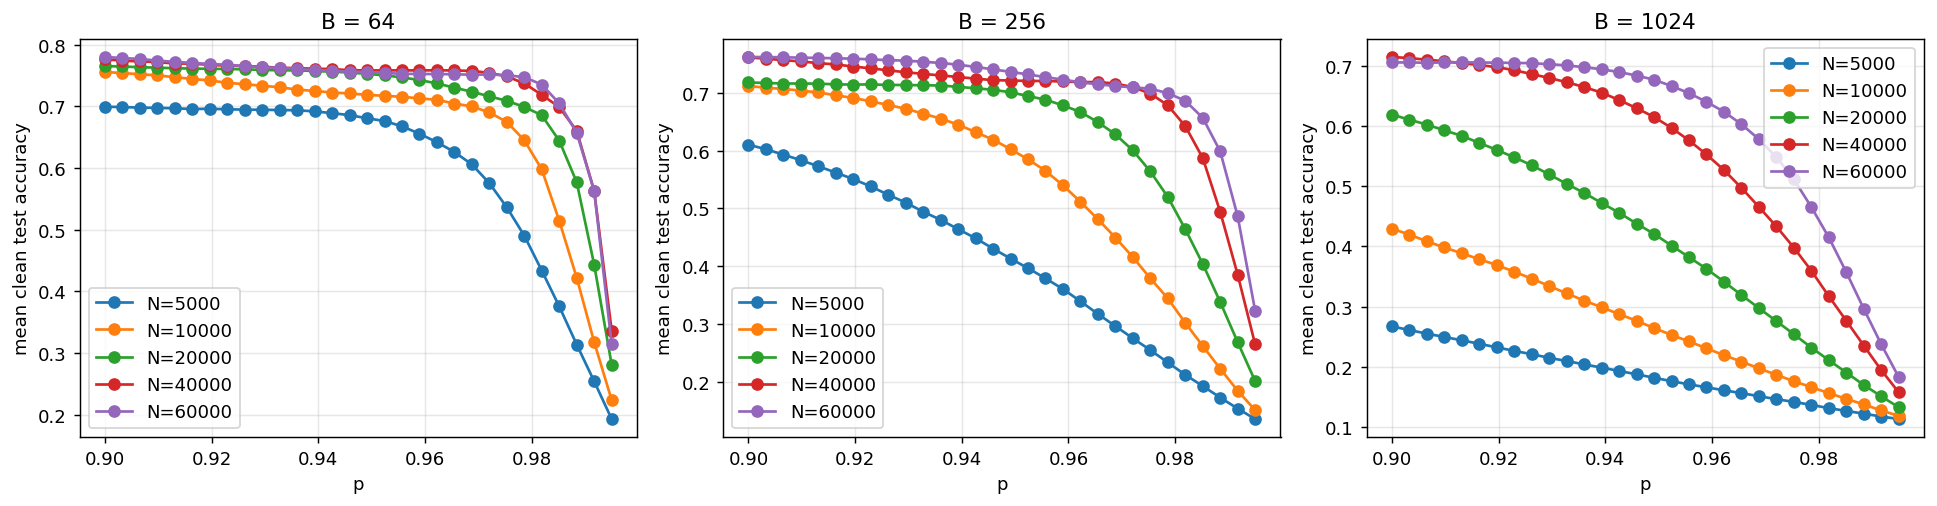

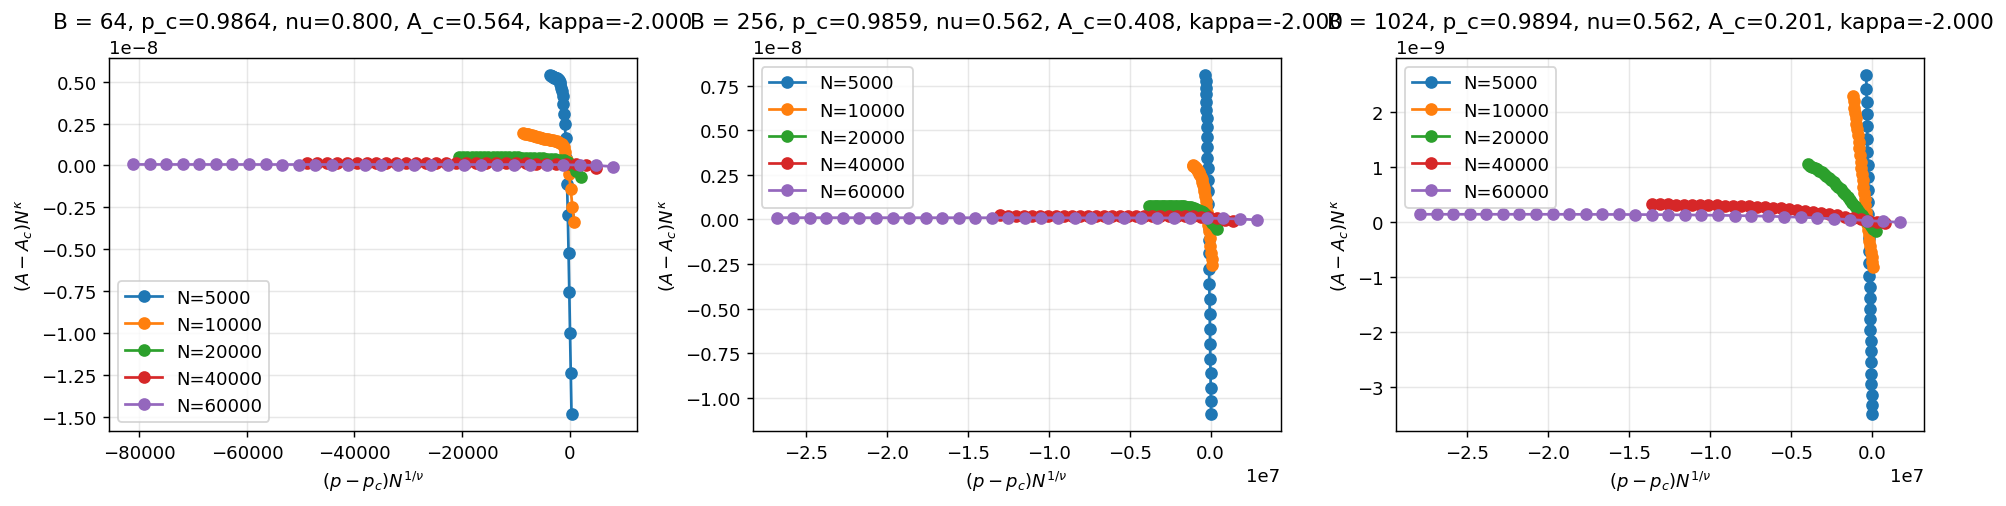

/tmp/ipykernel_829870/3529021526.py:296: DeprecationWarning: Please import `OptimizeResult` from the `scipy.optimize` namespace; the `scipy.optimize.optimize` namespace is deprecated and will be removed in SciPy 2.0.0.
  if not hasattr(_opt_mod, name) and hasattr(_opt, name):
/tmp/ipykernel_829870/3529021526.py:296: DeprecationWarning: Please import `OptimizeResult` from the `scipy.optimize` namespace; the `scipy.optimize.optimize` namespace is deprecated and will be removed in SciPy 2.0.0.
  if not hasattr(_opt_mod, name) and hasattr(_opt, name):
/tmp/ipykernel_829870/3529021526.py:296: DeprecationWarning: Please import `OptimizeResult` from the `scipy.optimize` namespace; the `scipy.optimize.optimize` namespace is deprecated and will be removed in SciPy 2.0.0.
  if not hasattr(_opt_mod, name) and hasattr(_opt, name):


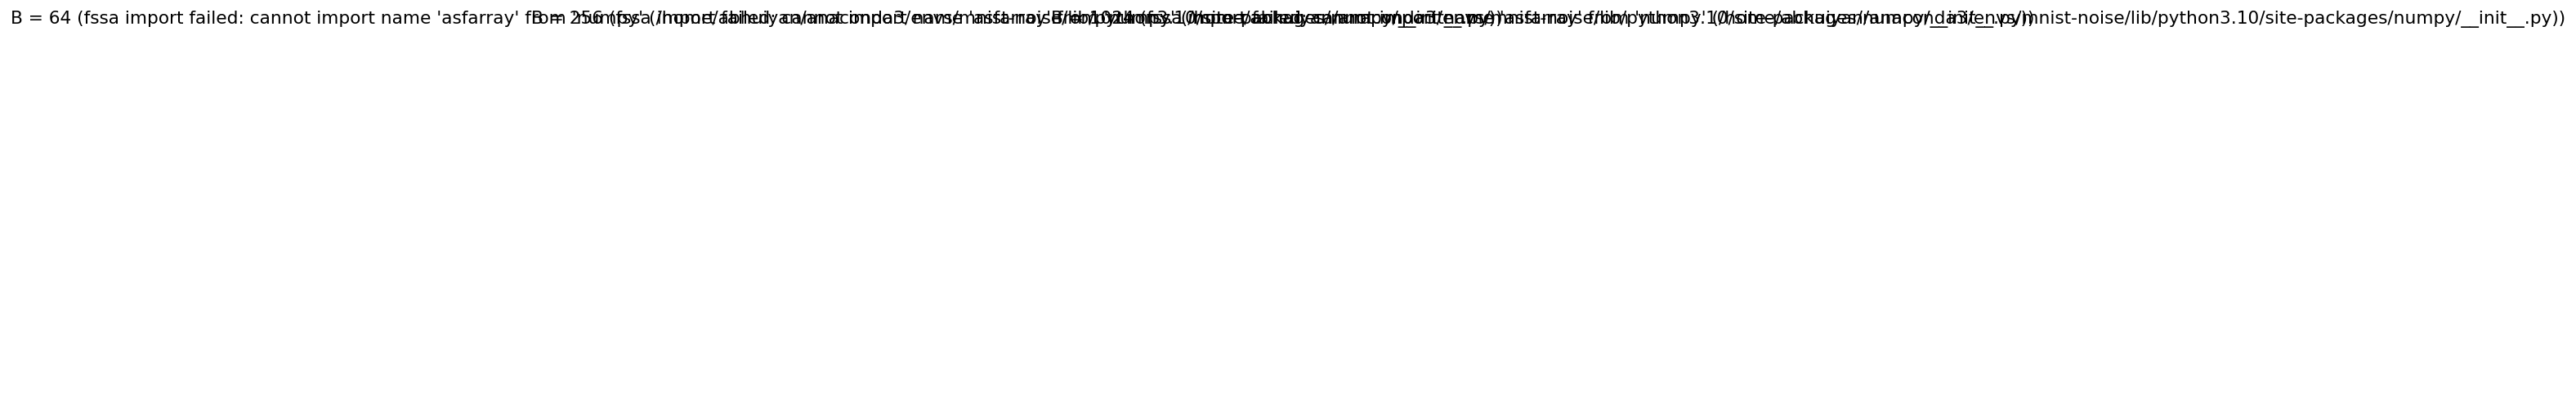

Custom collapse fits:


,batch_size,p_c,nu,A_c,kappa,score,n_points
0,64,0.9864,0.8000,0.564419,-2.0,1.319157e-18,150
1,256,0.9859,0.5625,0.408004,-2.0,1.084672e-18,150
2,1024,0.9894,0.5625,0.200764,-2.0,1.298311e-19,147


pyfssa collapse fits:


""


In [41]:
with PdfPages(FIGURES_DIR / 'finite_size_scaling_N_notebook.pdf') as pdf:
    fig, axes = plt.subplots(1, len(SCALING_BATCHES), figsize=(5 * len(SCALING_BATCHES), 4), squeeze=False)
    for idx, batch_size in enumerate(SCALING_BATCHES):
        ax = axes[0, idx]
        for n_value in n_values:
            sub = agg[(agg['N'] == n_value) & (agg['batch_size'] == batch_size)].sort_values('p')
            if len(sub) > 0:
                ax.plot(sub['p'], sub['mean_accuracy'], marker='o', label=f'N={n_value}')
        ax.set_title(f'B = {batch_size}')
        ax.set_xlabel('p')
        ax.set_ylabel('mean clean test accuracy')
        ax.legend()
    fig.tight_layout()
    save_figure(fig, 'finite_size_scaling_curves_notebook')
    pdf.savefig(fig)
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(1, len(SCALING_BATCHES), figsize=(5 * len(SCALING_BATCHES), 4), squeeze=False)
    collapse_rows = []
    for idx, batch_size in enumerate(SCALING_BATCHES):
        ax = axes[0, idx]
        sub = agg[agg['batch_size'] == batch_size].copy()
        if len(sub) == 0:
            ax.set_axis_off()
            continue
        fit = find_best_full_collapse(sub)
        if fit is None:
            ax.set_axis_off()
            ax.set_title(f'B = {batch_size} (insufficient data)')
            continue
        p_critical = fit['p_c']
        nu = fit['nu']
        a_critical = fit['A_c']
        kappa = fit['kappa']
        collapse_rows.append({'batch_size': batch_size, **fit})
        for n_value in sorted(sub['N'].unique()):
            sub_n = sub[sub['N'] == n_value].sort_values('p')
            scaled_x = (sub_n['p'].to_numpy(dtype=float) - p_critical) * np.power(float(n_value), 1.0 / nu)
            scaled_y = (sub_n['mean_accuracy'].to_numpy(dtype=float) - a_critical) * np.power(float(n_value), kappa)
            order = np.argsort(scaled_x)
            ax.plot(scaled_x[order], scaled_y[order], marker='o', label=f'N={n_value}')
        ax.set_title(f"B = {batch_size}, p_c={p_critical:.4f}, nu={nu:.3f}, A_c={a_critical:.3f}, kappa={kappa:.3f}")
        ax.set_xlabel(r'$(p-p_c)N^{1/\nu}$')
        ax.set_ylabel(r'$(A-A_c)N^{\kappa}$')
        ax.legend()
    fig.tight_layout()
    save_figure(fig, 'finite_size_collapse_notebook')
    pdf.savefig(fig)
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(1, len(SCALING_BATCHES), figsize=(5 * len(SCALING_BATCHES), 4), squeeze=False)
    pyfssa_rows = []
    for idx, batch_size in enumerate(SCALING_BATCHES):
        ax = axes[0, idx]
        sub = agg[agg['batch_size'] == batch_size].copy()
        if len(sub) == 0:
            ax.set_axis_off()
            continue
        result, scaled = find_pyfssa_collapse_zeta0_batch(sub)
        if scaled is None:
            ax.set_axis_off()
            ax.set_title(f"B = {batch_size} ({result.get('error', 'pyfssa failed')})")
            continue
        pyfssa_rows.append({'batch_size': batch_size, **result})
        for i, n_value in enumerate(result['n_values']):
            ax.plot(scaled.x[i], scaled.y[i], marker='o', linestyle='-', label=f'N={n_value}')
        ax.set_title(f"B = {batch_size}, p_c={result['rho_c']:.4f}, nu={result['nu']:.3f}, S={result['S']:.4g}", fontsize=9)
        ax.set_xlabel(r'$(p-p_c)N^{1/\nu}$')
        ax.set_ylabel(r'$A(p)-A(p_c)$')
        ax.legend()
    fig.tight_layout()
    save_figure(fig, 'finite_size_collapse_pyfssa_notebook')
    pdf.savefig(fig)
    plt.show()
    plt.close(fig)

print('Custom collapse fits:')
display(pd.DataFrame(collapse_rows))
print('pyfssa collapse fits:')
display(pd.DataFrame(pyfssa_rows))

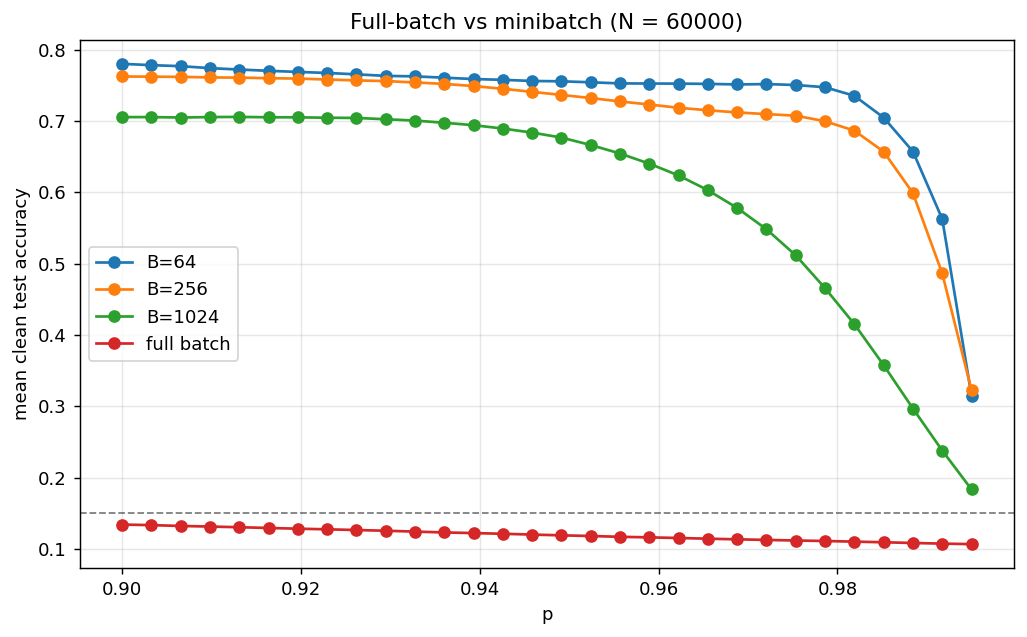

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
for batch_size in [64, 256, 1024, 60000]:
    sub = agg[(agg['N'] == 60000) & (agg['batch_size'] == batch_size)].sort_values('p')
    if len(sub) == 0:
        continue
    label = 'full batch' if batch_size == 60000 else f'B={batch_size}'
    ax.plot(sub['p'], sub['mean_accuracy'], marker='o', label=label)
ax.axhline(0.15, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Full-batch vs minibatch (N = 60000)')
ax.set_xlabel('p')
ax.set_ylabel('mean clean test accuracy')
ax.legend()
fig.tight_layout()
save_figure(fig, 'full_batch_vs_minibatch_notebook')
plt.show()
plt.close(fig)

Found 7500 run JSON files in /home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_r5_e50_p0.9000-0.9950_b16-60000_n5000-60000_w512_lr0.01_logtr100_logte500/runs


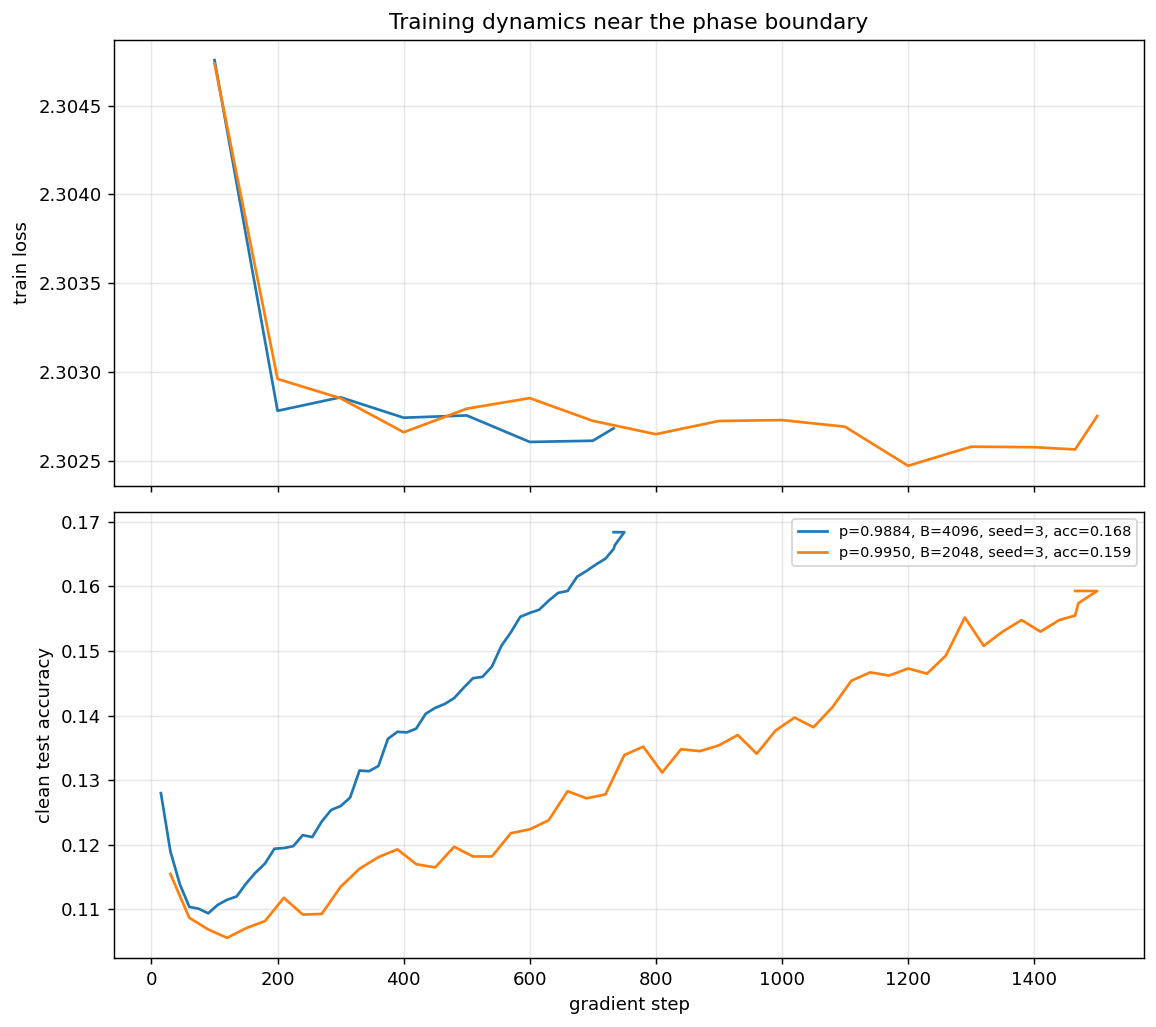

In [40]:
run_json_paths = sorted(RUNS_DIR.glob('*.json'))
print(f'Found {len(run_json_paths)} run JSON files in {RUNS_DIR}')

if run_json_paths:
    run_rows = []
    for path in run_json_paths:
        with path.open('r', encoding='utf-8') as handle:
            run_rows.append(json.load(handle))
    run_df = pd.DataFrame([
        {
            'p': row['p'],
            'batch_size': row['batch_size'],
            'N': row['N'],
            'seed': row['seed'],
            'final_test_accuracy': row['final_test_accuracy'],
            'train_loss_curve': row['train_loss_curve'],
            'test_acc_curve': row['test_acc_curve'],
        }
        for row in run_rows
    ])

    agg_60000 = aggregate_accuracy_only(run_df)
    candidates = agg_60000[agg_60000['N'] == 60000].copy()
    candidates['dist'] = (candidates['mean_accuracy'] - 0.15).abs()
    above = candidates[candidates['mean_accuracy'] > 0.15].sort_values('dist')
    below = candidates[candidates['mean_accuracy'] <= 0.15].sort_values('dist')
    chosen = pd.concat([above.head(1), below.head(1)], axis=0).drop_duplicates(subset=['N', 'batch_size', 'p'])

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
    for _, row in chosen.iterrows():
        matches = run_df[
            (run_df['N'] == row['N'])
            & (run_df['batch_size'] == row['batch_size'])
            & (run_df['p'] == row['p'])
        ].copy()
        if len(matches) == 0:
            continue
        matches['acc_dist'] = (matches['final_test_accuracy'] - row['mean_accuracy']).abs()
        best = matches.sort_values('acc_dist').iloc[0]
        label = f"p={best['p']:.4f}, B={int(best['batch_size'])}, seed={int(best['seed'])}, acc={best['final_test_accuracy']:.3f}"
        train_curve = np.asarray(best['train_loss_curve'], dtype=float)
        test_curve = np.asarray(best['test_acc_curve'], dtype=float)
        if train_curve.size:
            axes[0].plot(train_curve[:, 0], train_curve[:, 1], label=label)
        if test_curve.size:
            axes[1].plot(test_curve[:, 0], test_curve[:, 1], label=label)
    axes[0].set_title('Training dynamics near the phase boundary')
    axes[0].set_ylabel('train loss')
    axes[1].set_xlabel('gradient step')
    axes[1].set_ylabel('clean test accuracy')
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save_figure(fig, 'training_dynamics_notebook')
    plt.show()
    plt.close(fig)
else:
    print('No run JSON files found, so training dynamics cannot be reconstructed from the CSV alone.')